In [ ]:
# ============================================================
# NINTENDO COMPETITIVE ADVANTAGE PYRAMID
# STRAT 560
#
# Purpose:
# Build and compare Nintendo's:
#   1. Stated Competitive Advantage Pyramid
#   2. Revealed Competitive Advantage Pyramid
#
# Evidence hierarchy:
#   BASE   = values and priorities
#   MIDDLE = resources and capabilities
#   TOP    = activities
#
# The pipeline preserves source document and page number
# so every revealed conclusion can be traced to evidence.
# ============================================================

from pathlib import Path
import pandas as pd
import re
import json

# ------------------------------------------------------------
# PROJECT PATHS
# ------------------------------------------------------------

# ------------------------------------------------------------
# LOCAL / GOOGLE COLAB SETUP
# ------------------------------------------------------------

REPO_URL = "https://github.com/stevenmiguelramirez-netizen/Nintendo-Competitive-Advantage-Pyramid.git"
REPO_NAME = "Nintendo-Competitive-Advantage-Pyramid"

# Detect whether notebook is running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess

    repo_path = Path("/content") / REPO_NAME

    # Download the public GitHub repository if it is not already present
    if not repo_path.exists():
        subprocess.run(
            ["git", "clone", REPO_URL, str(repo_path)],
            check=True
        )

    PROJECT_DIR = repo_path

else:
    # Local VS Code / Jupyter
    PROJECT_DIR = Path.cwd()

REPORTS_DIR = PROJECT_DIR / "reports"
OUTPUT_DIR = PROJECT_DIR / "output"

REPORTS_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print("Nintendo Competitive Advantage Pyramid")
print("=" * 45)
print(f"Project folder: {PROJECT_DIR}")
print(f"Reports folder: {REPORTS_DIR}")
print(f"Output folder:  {OUTPUT_DIR}")

# ------------------------------------------------------------
# CHECK SOURCE DOCUMENTS
# ------------------------------------------------------------

pdf_files = sorted(REPORTS_DIR.glob("*.pdf"))

print("\nSOURCE DOCUMENT CHECK")
print("-" * 45)

if pdf_files:
    print(f"✓ Found {len(pdf_files)} PDF source document(s):\n")

    for i, pdf in enumerate(pdf_files, start=1):
        print(f"{i}. {pdf.name}")

else:
    print("⚠ No PDFs found.")
    print("Add Nintendo source documents to the reports folder.")

Nintendo Competitive Advantage Pyramid
Project folder: c:\Users\steve\Documents\ACC 525\Nintendo-Competitive-Advantage-Pyramid
Reports folder: c:\Users\steve\Documents\ACC 525\Nintendo-Competitive-Advantage-Pyramid\reports
Output folder:  c:\Users\steve\Documents\ACC 525\Nintendo-Competitive-Advantage-Pyramid\output

SOURCE DOCUMENT CHECK
---------------------------------------------
✓ Found 3 PDF source document(s):

1. Nintendo_2026_Convocation_Notice.pdf
2. Nintendo_2026_Shareholder_QA.pdf
3. Nintendo_Annual_Report_2026.pdf


In [79]:
# ============================================================
# CELL 2 — EXTRACT PDF TEXT PAGE BY PAGE
# ============================================================

# Install/import PDF reader
try:
    import pymupdf
except ImportError:
    %pip install pymupdf
    import pymupdf

extracted_pages = []

print("EXTRACTING SOURCE DOCUMENTS")
print("=" * 55)

for pdf_path in pdf_files:
    
    print(f"\nReading: {pdf_path.name}")
    
    document = pymupdf.open(pdf_path)
    
    for page_index in range(len(document)):
        
        page = document[page_index]
        text = page.get_text("text")
        
        extracted_pages.append({
            "document": pdf_path.name,
            "pdf_page": page_index + 1,
            "text": text.strip()
        })
    
    print(f"✓ Extracted {len(document)} pages")

    document.close()

# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------

pages_df = pd.DataFrame(extracted_pages)

# Remove completely blank pages
pages_df = pages_df[
    pages_df["text"].str.strip() != ""
].reset_index(drop=True)

# Save extraction
extraction_path = OUTPUT_DIR / "extracted_pages.csv"
pages_df.to_csv(extraction_path, index=False, encoding="utf-8-sig")

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("\nEXTRACTION COMPLETE")
print("=" * 55)

print(f"Loaded successfully: {not pages_df.empty}")
print(f"Rows (pages): {len(pages_df):,}")
print(f"Columns: {len(pages_df.columns)}")
print(f"Column names: {list(pages_df.columns)}")
print(f"Missing cells: {pages_df.isna().sum().sum():,}")
print(f"Duplicate rows: {pages_df.duplicated().sum():,}")

print("\nPages extracted by document:")
display(
    pages_df.groupby("document")
    .size()
    .reset_index(name="pages_extracted")
)

print("\nPreview:")
display(pages_df.head())

EXTRACTING SOURCE DOCUMENTS

Reading: Nintendo_2026_Convocation_Notice.pdf
✓ Extracted 12 pages

Reading: Nintendo_2026_Shareholder_QA.pdf
✓ Extracted 43 pages

Reading: Nintendo_Annual_Report_2026.pdf
✓ Extracted 103 pages

EXTRACTION COMPLETE
Loaded successfully: True
Rows (pages): 158
Columns: 3
Column names: ['document', 'pdf_page', 'text']
Missing cells: 0
Duplicate rows: 0

Pages extracted by document:


,document,pages_extracted
0,Nintendo_2026_Convocation_Notice.pdf,12
1,Nintendo_2026_Shareholder_QA.pdf,43
2,Nintendo_Annual_Report_2026.pdf,103



Preview:


,document,pdf_page,text
0,Nintendo_2026_Convocation_Notice.pdf,1,"Nintendo Co., Ltd. \n11-1..."
1,Nintendo_2026_Convocation_Notice.pdf,2,Consolidated Financial Forecast for the Fiscal...
2,Nintendo_2026_Convocation_Notice.pdf,3,Description of Operating Results\n1. Operating...
3,Nintendo_2026_Convocation_Notice.pdf,4,2. Outlook for the Fiscal Year Ending March 31...
4,Nintendo_2026_Convocation_Notice.pdf,5,Consolidated Balance Sheets\nmillion yen\n(Ass...


In [80]:
# ============================================================
# CELL 3 — IDENTIFY COMPETITIVE ADVANTAGE EVIDENCE
# ============================================================

# Evidence categories are based directly on the assignment rubric.
# These terms help locate candidate pages.
# A match is NOT automatically treated as evidence:
# candidate pages will be reviewed before entering the pyramid.

evidence_terms = {

    "BASE — Executive Compensation": [
        "compensation",
        "remuneration",
        "performance-linked",
        "performance based",
        "operating profit",
        "restricted stock"
    ],

    "BASE — Capital Allocation": [
        "research and development",
        "capital investment",
        "capital expenditure",
        "treasury shares",
        "share repurchase",
        "buyback",
        "dividend",
        "retained earnings"
    ],

    "MIDDLE — Resources": [
        "intellectual property",
        "IP",
        "cash and cash equivalents",
        "employees",
        "subsidiaries",
        "development facilities"
    ],

    "MIDDLE — Capabilities": [
        "development structure",
        "development capabilities",
        "research and development",
        "network infrastructure",
        "cloud computing",
        "deep learning",
        "big data",
        "development efficiency",
        "human resources",
        "talent"
    ],

    "TOP — Activities": [
        "dedicated video game platform",
        "hardware",
        "software",
        "digital sales",
        "IP related",
        "movies",
        "mobile",
        "merchandise",
        "real-world experiences"
    ],

    "STATED — Strategy and Priorities": [
        "long-term relationships",
        "Nintendo IP fanbase",
        "unique",
        "family-friendly",
        "entertainment",
        "smiles",
        "management policy"
    ]
}


# ------------------------------------------------------------
# SEARCH EVERY EXTRACTED PAGE
# ------------------------------------------------------------

evidence_hits = []

for _, row in pages_df.iterrows():

    text_lower = row["text"].lower()

    for category, terms in evidence_terms.items():

        matched_terms = [
            term for term in terms
            if term.lower() in text_lower
        ]

        if matched_terms:

            evidence_hits.append({
                "category": category,
                "document": row["document"],
                "pdf_page": row["pdf_page"],
                "matched_terms": ", ".join(matched_terms),
                "text": row["text"]
            })


evidence_df = pd.DataFrame(evidence_hits)

# Save candidate evidence
evidence_path = OUTPUT_DIR / "candidate_evidence.csv"
evidence_df.to_csv(
    evidence_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("COMPETITIVE ADVANTAGE EVIDENCE SEARCH")
print("=" * 60)

print(f"Loaded successfully: {not evidence_df.empty}")
print(f"Evidence hits: {len(evidence_df):,}")
print(f"Columns: {len(evidence_df.columns)}")
print(f"Column names: {list(evidence_df.columns)}")
print(f"Missing cells: {evidence_df.isna().sum().sum():,}")
print(f"Duplicate rows: {evidence_df.duplicated().sum():,}")

print("\nCandidate pages by category:")
display(
    evidence_df.groupby("category")
    .size()
    .reset_index(name="candidate_pages")
    .sort_values("category")
)

print("\nCandidate pages by source:")
display(
    evidence_df.groupby("document")
    .size()
    .reset_index(name="evidence_hits")
)

print("\nSample evidence:")
display(
    evidence_df[
        ["category", "document", "pdf_page", "matched_terms"]
    ].head(20)
)

COMPETITIVE ADVANTAGE EVIDENCE SEARCH
Loaded successfully: True
Evidence hits: 285
Columns: 5
Column names: ['category', 'document', 'pdf_page', 'matched_terms', 'text']
Missing cells: 0
Duplicate rows: 0

Candidate pages by category:


,category,candidate_pages
0,BASE — Capital Allocation,48
1,BASE — Executive Compensation,42
2,MIDDLE — Capabilities,23
3,MIDDLE — Resources,103
4,STATED — Strategy and Priorities,31
5,TOP — Activities,38



Candidate pages by source:


,document,evidence_hits
0,Nintendo_2026_Convocation_Notice.pdf,27
1,Nintendo_2026_Shareholder_QA.pdf,73
2,Nintendo_Annual_Report_2026.pdf,185



Sample evidence:


,category,document,pdf_page,matched_terms
0,BASE — Executive Compensation,Nintendo_2026_Convocation_Notice.pdf,1,operating profit
1,BASE — Capital Allocation,Nintendo_2026_Convocation_Notice.pdf,1,dividend
2,BASE — Executive Compensation,Nintendo_2026_Convocation_Notice.pdf,2,operating profit
3,BASE — Capital Allocation,Nintendo_2026_Convocation_Notice.pdf,2,"treasury shares, dividend"
4,BASE — Executive Compensation,Nintendo_2026_Convocation_Notice.pdf,3,operating profit
5,BASE — Capital Allocation,Nintendo_2026_Convocation_Notice.pdf,3,"treasury shares, dividend, retained earnings"
6,MIDDLE — Resources,Nintendo_2026_Convocation_Notice.pdf,3,"IP, cash and cash equivalents"
7,TOP — Activities,Nintendo_2026_Convocation_Notice.pdf,3,"dedicated video game platform, hardware, softw..."
8,BASE — Executive Compensation,Nintendo_2026_Convocation_Notice.pdf,4,operating profit
9,BASE — Capital Allocation,Nintendo_2026_Convocation_Notice.pdf,4,"capital investment, treasury shares, buyback, ..."


In [81]:
# ============================================================
# CELL 4 — RANK AND REVIEW CANDIDATE EVIDENCE
# ============================================================

# The broad search in Cell 3 intentionally favors recall.
# This cell ranks pages by the number of assignment-relevant
# search terms found on each page.
#
# IMPORTANT:
# A high score means "review this page."
# It does NOT mean the page automatically belongs in the pyramid.

review_df = evidence_df.copy()

# ------------------------------------------------------------
# COUNT MATCHED TERMS
# ------------------------------------------------------------

review_df["match_count"] = review_df["matched_terms"].apply(
    lambda x: len([term for term in x.split(", ") if term.strip()])
)

# ------------------------------------------------------------
# CREATE A SHORT TEXT PREVIEW
# ------------------------------------------------------------

def make_preview(text, length=500):
    clean_text = " ".join(str(text).split())

    if len(clean_text) > length:
        return clean_text[:length] + "..."

    return clean_text


review_df["preview"] = review_df["text"].apply(make_preview)

# ------------------------------------------------------------
# RANK WITHIN EACH CATEGORY
# ------------------------------------------------------------

review_df = review_df.sort_values(
    by=["category", "match_count", "document", "pdf_page"],
    ascending=[True, False, True, True]
).reset_index(drop=True)

# ------------------------------------------------------------
# SHOW TOP CANDIDATES FOR EACH CATEGORY
# ------------------------------------------------------------

categories = review_df["category"].unique()

for category in categories:

    print("\n")
    print("=" * 80)
    print(category)
    print("=" * 80)

    category_results = (
        review_df[review_df["category"] == category]
        [["document", "pdf_page", "match_count", "matched_terms", "preview"]]
        .head(8)
        .reset_index(drop=True)
    )

    display(category_results)

# ------------------------------------------------------------
# SAVE REVIEW FILE
# ------------------------------------------------------------

review_path = OUTPUT_DIR / "ranked_evidence_review.csv"

review_df.to_csv(
    review_path,
    index=False,
    encoding="utf-8-sig"
)

print("\n✓ Ranked evidence review saved to:")
print(review_path)



BASE — Capital Allocation


,document,pdf_page,match_count,matched_terms,preview
0,Nintendo_2026_Convocation_Notice.pdf,4,5,"capital investment, treasury shares, buyback, ...",2. Outlook for the Fiscal Year Ending March 31...
1,Nintendo_Annual_Report_2026.pdf,32,5,"capital investment, treasury shares, buyback, ...",- 30 - 3. Dividend policy It is the Company’s ...
2,Nintendo_2026_Shareholder_QA.pdf,5,4,"research and development, treasury shares, div...",5 Reference Documents for the General Meeting ...
3,Nintendo_Annual_Report_2026.pdf,2,4,"research and development, capital investment, ...",Table of Contents Information on the Company ....
4,Nintendo_Annual_Report_2026.pdf,20,4,"research and development, capital investment, ...",- 18 - (iii) Sales results Sales results in th...
5,Nintendo_2026_Convocation_Notice.pdf,3,3,"treasury shares, dividend, retained earnings",Description of Operating Results 1. Operating ...
6,Nintendo_2026_Convocation_Notice.pdf,9,3,"treasury shares, dividend, retained earnings",Consolidated Statements of Changes in Equity Y...
7,Nintendo_2026_Convocation_Notice.pdf,10,3,"treasury shares, dividend, retained earnings","Year ended March 31, 2026 (April 1, 2025 - Mar..."




BASE — Executive Compensation


,document,pdf_page,match_count,matched_terms,preview
0,Nintendo_2026_Shareholder_QA.pdf,28,4,"compensation, remuneration, operating profit, ...",28 Board of Directors after deliberation by th...
1,Nintendo_2026_Shareholder_QA.pdf,26,3,"compensation, operating profit, restricted stock",26 contract is to compensate for claims for le...
2,Nintendo_2026_Shareholder_QA.pdf,27,3,"compensation, remuneration, restricted stock",27 2) Resolutions by the General Meeting of Sh...
3,Nintendo_Annual_Report_2026.pdf,47,3,"compensation, operating profit, restricted stock","- 45 - (4) Compensation for officers, etc. (i)..."
4,Nintendo_Annual_Report_2026.pdf,48,3,"compensation, remuneration, operating profit",- 46 - This limit is reached when consolidated...
5,Nintendo_2026_Shareholder_QA.pdf,2,2,"compensation, restricted stock",2 3. Meeting Agenda: Matters to be reported: 1...
6,Nintendo_2026_Shareholder_QA.pdf,18,2,"compensation, restricted stock",18 Proposal No. 4: Revision of the Amount of C...
7,Nintendo_Annual_Report_2026.pdf,31,2,"compensation, restricted stock",- 29 - (4) Status of disposition and holding o...




MIDDLE — Capabilities


...



STATED — Strategy and Priorities


,document,pdf_page,match_count,matched_terms,preview
0,Nintendo_Annual_Report_2026.pdf,10,6,"Nintendo IP fanbase, unique, family-friendly, ...",- 8 - II. Business Overview 1. Management poli...
1,Nintendo_Annual_Report_2026.pdf,56,6,"long-term relationships, Nintendo IP fanbase, ...",- 54 - 5. Employees (1) Basic policies on Huma...
2,Nintendo_2026_Shareholder_QA.pdf,21,5,"long-term relationships, Nintendo IP fanbase, ...",21 create more reasons to choose Nintendo for ...
3,Nintendo_2026_Shareholder_QA.pdf,20,3,"unique, family-friendly, entertainment","20 Business Report (April 1, 2025 - March 31, ..."
4,Nintendo_Annual_Report_2026.pdf,14,3,"unique, family-friendly, entertainment",- 12 - 3. Risk factors Listed below are the va...
5,Nintendo_Annual_Report_2026.pdf,21,3,"unique, entertainment, smiles",- 19 - 6. Research and development activities ...
6,Nintendo_Annual_Report_2026.pdf,57,3,"unique, family-friendly, entertainment",- 55 - To assess the status of individual deve...
7,Nintendo_2026_Shareholder_QA.pdf,10,2,"unique, entertainment",10 Candidate No. 9 Kazuhiko Hachiya Reelection...




TOP — Activities


,document,pdf_page,match_count,matched_terms,preview
0,Nintendo_2026_Shareholder_QA.pdf,20,8,"dedicated video game platform, hardware, softw...","20 Business Report (April 1, 2025 - March 31, ..."
1,Nintendo_Annual_Report_2026.pdf,10,7,"dedicated video game platform, hardware, softw...",- 8 - II. Business Overview 1. Management poli...
2,Nintendo_Annual_Report_2026.pdf,92,7,"dedicated video game platform, hardware, softw...",- 90 - Revenue recognition 1. Breakdown of rev...
3,Nintendo_2026_Shareholder_QA.pdf,22,6,"dedicated video game platform, hardware, softw...",22 (5) Material Subsidiaries Company name Capi...
4,Nintendo_Annual_Report_2026.pdf,7,6,"dedicated video game platform, hardware, softw...",- 5 - 3. Description of business In the field ...
5,Nintendo_2026_Convocation_Notice.pdf,3,5,"dedicated video game platform, hardware, softw...",Description of Operating Results 1. Operating ...
6,Nintendo_Annual_Report_2026.pdf,17,5,"dedicated video game platform, hardware, softw...","- 15 - 4. Analysis of financial position, oper..."
7,Nintendo_Annual_Report_2026.pdf,69,5,"dedicated video game platform, hardware, softw...",- 67 - (6) Amortization method and amortizatio...



✓ Ranked evidence review saved to:
c:\Users\steve\Documents\ACC 525\Nintendo-Competitive-Advantage-Pyramid\output\ranked_evidence_review.csv


In [82]:
# ============================================================
# CELL 5 — INSPECT HIGH-VALUE EVIDENCE PAGES
# ============================================================

# These pages were identified by the evidence-ranking stage
# as especially relevant to the assignment.
#
# We inspect the full extracted text before deciding whether
# any evidence belongs in the final revealed pyramid.

pages_to_inspect = [
    
    # Executive compensation
    ("Nintendo_Annual_Report_2026.pdf", 47),
    ("Nintendo_Annual_Report_2026.pdf", 48),

    # Capital allocation / financial priorities
    ("Nintendo_Annual_Report_2026.pdf", 20),
    ("Nintendo_Annual_Report_2026.pdf", 32),

    # Resources / capabilities
    ("Nintendo_Annual_Report_2026.pdf", 21),

    # Actual activities / revenue
    ("Nintendo_Annual_Report_2026.pdf", 92),

    # Stated strategy
    ("Nintendo_Annual_Report_2026.pdf", 10),
]


print("HIGH-VALUE EVIDENCE REVIEW")
print("=" * 80)

for document_name, page_number in pages_to_inspect:

    result = pages_df[
        (pages_df["document"] == document_name) &
        (pages_df["pdf_page"] == page_number)
    ]

    print("\n")
    print("#" * 80)
    print(f"SOURCE: {document_name}")
    print(f"PDF PAGE: {page_number}")
    print("#" * 80)

    if result.empty:
        print("❌ Page not found.")
    else:
        print(result.iloc[0]["text"])

HIGH-VALUE EVIDENCE REVIEW


################################################################################
SOURCE: Nintendo_Annual_Report_2026.pdf
PDF PAGE: 47
################################################################################
- 45 - 
 
(4) Compensation for officers, etc. 
(i) Policy, etc. for the determination of compensation, etc. for officers or calculation method thereof 
The Company has established the following policy (hereinafter referred to as the “Decision Policy”) for 
determining the details of compensation to individual Directors. The Decision Policy was established by resolution 
of the Board of Directors, after deliberation by the Nomination Advisory Committee. 
The compensation for the Company’s Directors who are not Audit and Supervisory Committee Members and 
Directors who are Audit and Supervisory Committee Members is determined within their respective upper limits 
which are established by resolution of the General Meeting of Shareholders. 
The Compa

In [83]:
#CELL 5.5 Show only executive compensation pages for review

for page_number in [47, 48]:

    text = pages_df[
        (pages_df["document"] == "Nintendo_Annual_Report_2026.pdf") &
        (pages_df["pdf_page"] == page_number)
    ].iloc[0]["text"]

    print("\n" + "=" * 80)
    print(f"ANNUAL REPORT — PDF PAGE {page_number}")
    print("=" * 80)
    print(text)


ANNUAL REPORT — PDF PAGE 47
- 45 - 
 
(4) Compensation for officers, etc. 
(i) Policy, etc. for the determination of compensation, etc. for officers or calculation method thereof 
The Company has established the following policy (hereinafter referred to as the “Decision Policy”) for 
determining the details of compensation to individual Directors. The Decision Policy was established by resolution 
of the Board of Directors, after deliberation by the Nomination Advisory Committee. 
The compensation for the Company’s Directors who are not Audit and Supervisory Committee Members and 
Directors who are Audit and Supervisory Committee Members is determined within their respective upper limits 
which are established by resolution of the General Meeting of Shareholders. 
The Company uses results of a compensation survey by an external research agency as a reference for setting 
compensation standards, etc. The Company has also established a system in which matters related to compensation 
ar

In [84]:
# ============================================================
# CELL 6 — CURATED EVIDENCE REGISTER
# ============================================================

# Evidence enters this register only after:
#   1. automated discovery,
#   2. human review of the underlying passage, and
#   3. a documented interpretation.
#
# Evidence and interpretation remain separate so the final
# pyramid can distinguish observed behavior from our inference.

curated_evidence = [

    # ========================================================
    # REVEALED BASE — VALUES / PRIORITIES
    # ========================================================

    {
        "pyramid": "Revealed",
        "layer": "Base",
        "classification": "Priority",
        "element": "Sustained operating profitability",
        "evidence_type": "Executive compensation",
        "evidence": (
            "Performance-based Director compensation uses consolidated "
            "operating profit as its benchmark. An additional incentive "
            "is paid when both current-year operating profit and the "
            "three-year average exceed ¥400 billion."
        ),
        "interpretation": (
            "Nintendo financially rewards operating performance while "
            "also incorporating a multi-year profitability measure."
        ),
        "document": "Nintendo Annual Report 2026",
        "section": "Compensation for officers, etc.",
        "printed_page": "45–46",
        "pdf_page": "47–48"
    },

    {
        "pyramid": "Revealed",
        "layer": "Base",
        "classification": "Priority",
        "element": "Sustained operating profitability",
        "evidence_type": "Dividend policy",
        "evidence": (
            "Nintendo's annual dividend is determined using the higher "
            "of a formula based on 40% of consolidated operating profit "
            "or a 60% consolidated dividend payout ratio."
        ),
        "interpretation": (
            "Operating profit affects not only executive incentives but "
            "also shareholder distributions, reinforcing its importance "
            "in Nintendo's financial priorities."
        ),
        "document": "Nintendo Annual Report 2026",
        "section": "Dividend policy",
        "printed_page": "30",
        "pdf_page": "32"
    },

    {
        "pyramid": "Revealed",
        "layer": "Base",
        "classification": "Priority",
        "element": "Reinvestment for future growth",
        "evidence_type": "Capital allocation",
        "evidence": (
            "Nintendo states that retained earnings are maintained for "
            "research of new technology, development of new products and "
            "services, capital investment, securing materials, advertising, "
            "network infrastructure and potential treasury-share buybacks."
        ),
        "interpretation": (
            "Nintendo preserves substantial financial resources for "
            "technology, product development and infrastructure rather "
            "than distributing all available capital."
        ),
        "document": "Nintendo Annual Report 2026",
        "section": "Dividend policy",
        "printed_page": "30",
        "pdf_page": "32"
    },

    {
        "pyramid": "Revealed",
        "layer": "Base",
        "classification": "Priority",
        "element": "Reinvestment for future growth",
        "evidence_type": "R&D spending",
        "evidence": (
            "Research and development expenses for the fiscal year "
            "were ¥177.8 billion."
        ),
        "interpretation": (
            "The scale of actual R&D spending provides behavioral "
            "evidence that product and technology development receive "
            "significant resources."
        ),
        "document": "Nintendo Annual Report 2026",
        "section": "Research and development activities",
        "printed_page": "19",
        "pdf_page": "21"
    },

    {
        "pyramid": "Revealed",
        "layer": "Base",
        "classification": "Priority",
        "element": "Financial resilience and self-financing",
        "evidence_type": "Capital and liquidity policy",
        "evidence": (
            "Nintendo maintains retained earnings to adapt to changes "
            "in the business environment and pursue future expansion. "
            "Its basic policy is to internally provide capital necessary "
            "for future growth, including capital investments."
        ),
        "interpretation": (
            "Nintendo prioritizes maintaining enough internal liquidity "
            "to fund strategic investments and withstand uncertainty "
            "without depending primarily on external financing."
        ),
        "document": "Nintendo Annual Report 2026",
        "section": "Financial source of capital and liquidity of funds",
        "printed_page": "18",
        "pdf_page": "20"
    },

    # ========================================================
    # REVEALED MIDDLE — RESOURCES
    # ========================================================

    {
        "pyramid": "Revealed",
        "layer": "Middle",
        "classification": "Resource",
        "element": "Development facilities and infrastructure",
        "evidence_type": "Capital investment",
        "evidence": (
            "Nintendo invested ¥49.293 billion during FY2026, mainly "
            "in research and development facilities, including internal-use "
            "computer software. All capital investment was self-financed."
        ),
        "interpretation": (
            "Nintendo possesses and continues funding physical and "
            "digital infrastructure dedicated to product development."
        ),
        "document": "Nintendo Annual Report 2026",
        "section": "Overview of capital investments",
        "printed_page": "21",
        "pdf_page": "23"
    },

    {
        "pyramid": "Revealed",
        "layer": "Middle",
        "classification": "Resource",
        "element": "Specialized human capital",
        "evidence_type": "Employees",
        "evidence": (
            "Nintendo and its consolidated subsidiaries employed "
            "8,666 people as of March 31, 2026."
        ),
        "interpretation": (
            "Nintendo maintains a substantial internal workforce supporting "
            "the development, operation and commercialization of its "
            "entertainment products."
        ),
        "document": "Nintendo Annual Report 2026",
        "section": "Employees",
        "printed_page": "55",
        "pdf_page": "57"
    },

    # ========================================================
    # REVEALED MIDDLE — CAPABILITIES
    # ========================================================

    {
        "pyramid": "Revealed",
        "layer": "Middle",
        "classification": "Capability",
        "element": "Integrated hardware and software development",
        "evidence_type": "R&D activity",
        "evidence": (
            "Nintendo actively develops both hardware and software for "
            "dedicated video game systems. Its software development uses "
            "hardware features in game design and program development, "
            "while hardware research spans components, interfaces, "
            "networks and other technologies."
        ),
        "interpretation": (
            "Nintendo demonstrates an organizational capability to coordinate "
            "hardware and software development as an integrated system."
        ),
        "document": "Nintendo Annual Report 2026",
        "section": "Research and development activities",
        "printed_page": "19",
        "pdf_page": "21"
    },

    {
        "pyramid": "Revealed",
        "layer": "Middle",
        "classification": "Capability",
        "element": "Digital and network service development",
        "evidence_type": "R&D activity",
        "evidence": (
            "Nintendo expanded system infrastructure supporting network "
            "services, including software network features and Nintendo "
            "eShop, and established an R&D structure for smart-device "
            "software and back-end server development."
        ),
        "interpretation": (
            "Nintendo demonstrates the capability to develop and maintain "
            "digital services and network infrastructure alongside its "
            "traditional hardware and software products."
        ),
        "document": "Nintendo Annual Report 2026",
        "section": "Research and development activities",
        "printed_page": "19",
        "pdf_page": "21"
    },

    # ========================================================
    # REVEALED TOP — ACTIVITIES
    # ========================================================

    {
        "pyramid": "Revealed",
        "layer": "Top",
        "classification": "Activity",
        "element": "Dedicated video game platform business",
        "evidence_type": "Revenue mix",
        "evidence": (
            "FY2026 sales from the dedicated video game platform were "
            "¥2,239.541 billion, compared with ¥73.510 billion from "
            "IP-related income and other activities."
        ),
        "interpretation": (
            "Nintendo's economic activity remains overwhelmingly "
            "concentrated in its dedicated gaming platform despite "
            "its expansion of IP into other forms of entertainment."
        ),
        "document": "Nintendo Annual Report 2026",
        "section": "Sales results",
        "printed_page": "18",
        "pdf_page": "20"
    }
]

curated_evidence_df = pd.DataFrame(curated_evidence)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

curated_path = OUTPUT_DIR / "curated_evidence.csv"

curated_evidence_df.to_csv(
    curated_path,
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("CURATED EVIDENCE REGISTER")
print("=" * 70)

print(f"Loaded successfully: {not curated_evidence_df.empty}")
print(f"Rows: {len(curated_evidence_df):,}")
print(f"Columns: {len(curated_evidence_df.columns)}")
print(f"Column names: {list(curated_evidence_df.columns)}")
print(f"Missing cells: {curated_evidence_df.isna().sum().sum():,}")
print(f"Duplicate rows: {curated_evidence_df.duplicated().sum():,}")

print("\nEvidence by pyramid layer:")
display(
    curated_evidence_df.groupby(
        ["pyramid", "layer", "classification", "element"]
    )
    .size()
    .reset_index(name="supporting_evidence")
)

print("\nFull evidence register:")
display(curated_evidence_df)

CURATED EVIDENCE REGISTER
Loaded successfully: True
Rows: 10
Columns: 11
Column names: ['pyramid', 'layer', 'classification', 'element', 'evidence_type', 'evidence', 'interpretation', 'document', 'section', 'printed_page', 'pdf_page']
Missing cells: 0
Duplicate rows: 0

Evidence by pyramid layer:


,pyramid,layer,classification,element,supporting_evidence
0,Revealed,Base,Priority,Financial resilience and self-financing,1
1,Revealed,Base,Priority,Reinvestment for future growth,2
2,Revealed,Base,Priority,Sustained operating profitability,2
3,Revealed,Middle,Capability,Digital and network service development,1
4,Revealed,Middle,Capability,Integrated hardware and software development,1
5,Revealed,Middle,Resource,Development facilities and infrastructure,1
6,Revealed,Middle,Resource,Specialized human capital,1
7,Revealed,Top,Activity,Dedicated video game platform business,1



Full evidence register:


,pyramid,layer,classification,element,evidence_type,evidence,interpretation,document,section,printed_page,pdf_page
0,Revealed,Base,Priority,Sustained operating profitability,Executive compensation,Performance-based Director compensation uses c...,Nintendo financially rewards operating perform...,Nintendo Annual Report 2026,"Compensation for officers, etc.",45–46,47–48
1,Revealed,Base,Priority,Sustained operating profitability,Dividend policy,Nintendo's annual dividend is determined using...,Operating profit affects not only executive in...,Nintendo Annual Report 2026,Dividend policy,30,32
2,Revealed,Base,Priority,Reinvestment for future growth,Capital allocation,Nintendo states that retained earnings are mai...,Nintendo preserves substantial financial resou...,Nintendo Annual Report 2026,Dividend policy,30,32
3,Revealed,Base,Priority,Reinvestment for future growth,R&D spending,Research and development expenses for the fisc...,The scale of actual R&D spending provides beha...,Nintendo Annual Report 2026,Research and development activities,19,21
4,Revealed,Base,Priority,Financial resilience and self-financing,Capital and liquidity policy,Nintendo maintains retained earnings to adapt ...,Nintendo prioritizes maintaining enough intern...,Nintendo Annual Report 2026,Financial source of capital and liquidity of f...,18,20
5,Revealed,Middle,Resource,Development facilities and infrastructure,Capital investment,Nintendo invested ¥49.293 billion during FY202...,Nintendo possesses and continues funding physi...,Nintendo Annual Report 2026,Overview of capital investments,21,23
6,Revealed,Middle,Resource,Specialized human capital,Employees,Nintendo and its consolidated subsidiaries emp...,Nintendo maintains a substantial internal work...,Nintendo Annual Report 2026,Employees,55,57
7,Revealed,Middle,Capability,Integrated hardware and software development,R&D activity,Nintendo actively develops both hardware and s...,Nintendo demonstrates an organizational capabi...,Nintendo Annual Report 2026,Research and development activities,19,21
8,Revealed,Middle,Capability,Digital and network service development,R&D activity,Nintendo expanded system infrastructure suppor...,Nintendo demonstrates the capability to develo...,Nintendo Annual Report 2026,Research and development activities,19,21
9,Revealed,Top,Activity,Dedicated video game platform business,Revenue mix,FY2026 sales from the dedicated video game pla...,Nintendo's economic activity remains overwhelm...,Nintendo Annual Report 2026,Sales results,18,20


In [85]:
# ============================================================
# CELL 7 — MIDDLE-LAYER EVIDENCE REVIEW
# Resources vs. Capabilities
# ============================================================

middle_pages = [21, 23, 24, 57, 58]

print("MIDDLE-LAYER EVIDENCE REVIEW")
print("=" * 80)

for page_number in middle_pages:

    result = pages_df[
        (pages_df["document"] == "Nintendo_Annual_Report_2026.pdf") &
        (pages_df["pdf_page"] == page_number)
    ]

    print("\n")
    print("#" * 80)
    print(f"NINTENDO ANNUAL REPORT 2026 — PDF PAGE {page_number}")
    print("#" * 80)

    if result.empty:
        print("❌ Page not found.")
    else:
        print(result.iloc[0]["text"])

MIDDLE-LAYER EVIDENCE REVIEW


################################################################################
NINTENDO ANNUAL REPORT 2026 — PDF PAGE 21
################################################################################
- 19 - 
 
6. Research and development activities 
Nintendo (the Company and its consolidated subsidiaries) primarily engages in the active development of hardware 
and software for dedicated video game systems, with support from various companies and organizations, in its effort 
to put smiles on the faces of everyone Nintendo touches around the world by offering Nintendo’s unique, family-
friendly entertainment full of new surprises and fun. We also utilize Nintendo IP, focusing on the production of 
products such as those related to amiibo and movies and videos, and undertake the planning, development and 
operation of games that many people around the world can enjoy in the form of smart-device applications. 
With respect to hardware, we continuously i

In [86]:
# ============================================================
# CELL 8 — CAPITAL ALLOCATION EVIDENCE REVIEW
# ============================================================
capital_pages = [20, 21, 32]

print("CAPITAL ALLOCATION EVIDENCE")
print("=" * 80)

for page_number in capital_pages:

    result = pages_df[
        (pages_df["document"] == "Nintendo_Annual_Report_2026.pdf") &
        (pages_df["pdf_page"] == page_number)
    ]

    print("\n")
    print("#" * 80)
    print(f"NINTENDO ANNUAL REPORT 2026 — PDF PAGE {page_number}")
    print("#" * 80)

    if result.empty:
        print("❌ Page not found.")
    else:
        print(result.iloc[0]["text"])

CAPITAL ALLOCATION EVIDENCE


################################################################################
NINTENDO ANNUAL REPORT 2026 — PDF PAGE 20
################################################################################
- 18 - 
 
(iii) Sales results 
Sales results in the fiscal year ended March 31, 2026 were as follows. As Nintendo operates as a single business 
segment, the information is presented by product type. 
 
Type 
Amount 
Year-on-year increase (decrease) 
(%) 
(millions of yen) 
(millions of dollars) 
Dedicated video game platform 
2,239,541 
14,085 
106.7 
IP related income, etc. 
73,510 
462 
(9.7) 
Total 
2,313,051 
14,547 
98.6 
 
(4) Factors which have a significant impact on operating results, etc. 
Nintendo operates as a business in the field of home entertainment, in which the presence or lack of hit products 
and their sales volumes may have a significant impact on its operating results, etc. In addition, the field of 
entertainment is wide in scope, a

In [87]:
# ============================================================
# CELL 9 — STATED PYRAMID EVIDENCE REVIEW
# ============================================================

# PURPOSE:
# Find Nintendo's strongest explicit statements about:
#
#   BASE:
#       Values, priorities, and strategic objectives
#
#   MIDDLE:
#       Resources and capabilities Nintendo says it relies on
#
#   TOP:
#       Activities and strategic actions Nintendo says it pursues
#
# IMPORTANT:
# This cell searches Nintendo's own statements.
# It does NOT decide what Nintendo actually prioritizes in practice.
# Behavioral evidence belongs in the Revealed Pyramid.


# ------------------------------------------------------------
# STATED-STRATEGY SEARCH TERMS
# ------------------------------------------------------------

stated_search_terms = {

    "Base — Values and Priorities": [
        "basic strategy",
        "basic policy",
        "management policy",
        "highest emphasis",
        "smiles",
        "unique entertainment",
        "new forms of entertainment",
        "long-term relationships",
        "long term relationships",
        "Nintendo IP fanbase",
        "corporate value"
    ],

    "Middle — Resources and Capabilities": [
        "integrated hardware and software",
        "hardware and software",
        "Nintendo IP",
        "Nintendo Account",
        "development structure",
        "development capabilities",
        "human resources",
        "technology",
        "research and development",
        "direct connections"
    ],

    "Top — Activities and Strategy": [
        "dedicated video game",
        "movies",
        "videos",
        "mobile applications",
        "smart-device applications",
        "character merchandise",
        "real-world experiences",
        "Nintendo Switch 2",
        "expand",
        "expanding",
        "IP-related"
    ]
}


# ------------------------------------------------------------
# SEARCH EXTRACTED PDF PAGES
# ------------------------------------------------------------

stated_results = []

for category, terms in stated_search_terms.items():

    for _, row in pages_df.iterrows():

        text_lower = str(row["text"]).lower()

        matched_terms = [
            term
            for term in terms
            if term.lower() in text_lower
        ]

        if matched_terms:

            stated_results.append({
                "category": category,
                "document": row["document"],
                "pdf_page": row["pdf_page"],
                "match_count": len(matched_terms),
                "matched_terms": ", ".join(matched_terms),
                "preview": str(row["text"])[:700].replace("\n", " ")
            })


stated_review_df = pd.DataFrame(stated_results)


# ------------------------------------------------------------
# RANK STRONGEST PAGES
# ------------------------------------------------------------

stated_review_df = (
    stated_review_df
    .sort_values(
        ["category", "match_count"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

stated_review_path = OUTPUT_DIR / "stated_evidence_review.csv"

stated_review_df.to_csv(
    stated_review_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("STATED PYRAMID EVIDENCE REVIEW")
print("=" * 80)

print(f"Loaded successfully: {not stated_review_df.empty}")
print(f"Rows: {len(stated_review_df):,}")
print(f"Columns: {len(stated_review_df.columns)}")
print(f"Column names: {list(stated_review_df.columns)}")
print(f"Missing cells: {stated_review_df.isna().sum().sum():,}")
print(f"Duplicate rows: {stated_review_df.duplicated().sum():,}")


# ------------------------------------------------------------
# DISPLAY TOP CANDIDATES BY PYRAMID LAYER
# ------------------------------------------------------------

for category in stated_search_terms.keys():

    print("\n")
    print("=" * 80)
    print(category.upper())
    print("=" * 80)

    category_df = (
        stated_review_df[
            stated_review_df["category"] == category
        ]
        .head(8)
        .reset_index(drop=True)
    )

    display(category_df)

STATED PYRAMID EVIDENCE REVIEW
Loaded successfully: True
Rows: 76
Columns: 6
Column names: ['category', 'document', 'pdf_page', 'match_count', 'matched_terms', 'preview']
Missing cells: 0
Duplicate rows: 0


BASE — VALUES AND PRIORITIES


,category,document,pdf_page,match_count,matched_terms,preview
0,Base — Values and Priorities,Nintendo_Annual_Report_2026.pdf,10,6,"management policy, highest emphasis, smiles, n...",- 8 - II. Business Overview 1. Management ...
1,Base — Values and Priorities,Nintendo_2026_Shareholder_QA.pdf,21,4,"unique entertainment, long-term relationships,...",21 create more reasons to choose Nintendo f...
2,Base — Values and Priorities,Nintendo_Annual_Report_2026.pdf,56,3,"smiles, long-term relationships, Nintendo IP f...",- 54 - 5. Employees (1) Basic policies on ...
3,Base — Values and Priorities,Nintendo_Annual_Report_2026.pdf,57,3,"basic policy, unique entertainment, corporate ...",- 55 - To assess the status of individual d...
4,Base — Values and Priorities,Nintendo_Annual_Report_2026.pdf,37,2,"basic policy, corporate value",- 35 - (iv) Basic policy regarding the Co...
5,Base — Values and Priorities,Nintendo_2026_Convocation_Notice.pdf,1,1,basic policy,"Nintendo Co., Ltd. 11-1 ..."
6,Base — Values and Priorities,Nintendo_2026_Convocation_Notice.pdf,4,1,basic policy,2. Outlook for the Fiscal Year Ending March 31...
7,Base — Values and Priorities,Nintendo_2026_Shareholder_QA.pdf,3,1,basic policy,3 Information on Exercise of Voting Rights ...




MIDDLE — RESOURCES AND CAPABILITIES


,category,document,pdf_page,match_count,matched_terms,preview
0,Middle — Resources and Capabilities,Nintendo_Annual_Report_2026.pdf,10,5,"Nintendo IP, Nintendo Account, development str...",- 8 - II. Business Overview 1. Management ...
1,Middle — Resources and Capabilities,Nintendo_Annual_Report_2026.pdf,21,5,"Nintendo IP, Nintendo Account, development str...",- 19 - 6. Research and development activiti...
2,Middle — Resources and Capabilities,Nintendo_Annual_Report_2026.pdf,7,3,"hardware and software, technology, research an...",- 5 - 3. Description of business In the fi...
3,Middle — Resources and Capabilities,Nintendo_2026_Shareholder_QA.pdf,7,2,"development capabilities, technology",7 Candidate No. 3 Shinya Takahashi Reele...
4,Middle — Resources and Capabilities,Nintendo_2026_Shareholder_QA.pdf,8,2,"development capabilities, technology",8 Candidate No. 5 Ko Shiota Reelection ...
5,Middle — Resources and Capabilities,Nintendo_2026_Shareholder_QA.pdf,20,2,"technology, research and development","20 Business Report (April 1, 2025 - March ..."
6,Middle — Resources and Capabilities,Nintendo_2026_Shareholder_QA.pdf,21,2,"Nintendo IP, Nintendo Account",21 create more reasons to choose Nintendo f...
7,Middle — Resources and Capabilities,Nintendo_Annual_Report_2026.pdf,14,2,"technology, research and development",- 12 - 3. Risk factors Listed below are th...




TOP — ACTIVITIES AND STRATEGY


,category,document,pdf_page,match_count,matched_terms,preview
0,Top — Activities and Strategy,Nintendo_2026_Shareholder_QA.pdf,22,6,"dedicated video game, movies, videos, mobile a...",22 (5) Material Subsidiaries Company na...
1,Top — Activities and Strategy,Nintendo_Annual_Report_2026.pdf,10,6,"dedicated video game, movies, videos, real-wor...",- 8 - II. Business Overview 1. Management ...
2,Top — Activities and Strategy,Nintendo_2026_Shareholder_QA.pdf,20,5,"dedicated video game, movies, videos, real-wor...","20 Business Report (April 1, 2025 - March ..."
3,Top — Activities and Strategy,Nintendo_Annual_Report_2026.pdf,7,5,"dedicated video game, movies, videos, mobile a...",- 5 - 3. Description of business In the fi...
4,Top — Activities and Strategy,Nintendo_Annual_Report_2026.pdf,21,5,"dedicated video game, movies, videos, smart-de...",- 19 - 6. Research and development activiti...
5,Top — Activities and Strategy,Nintendo_2026_Shareholder_QA.pdf,21,3,"dedicated video game, Nintendo Switch 2, expand",21 create more reasons to choose Nintendo f...
6,Top — Activities and Strategy,Nintendo_Annual_Report_2026.pdf,92,3,"dedicated video game, movies, videos",- 90 - Revenue recognition 1. Breakdown of...
7,Top — Activities and Strategy,Nintendo_2026_Convocation_Notice.pdf,3,2,"dedicated video game, Nintendo Switch 2",Description of Operating Results 1. Operating ...


In [88]:
# ============================================================
# CELL 9.5 — INSPECT HIGH-VALUE STATED STRATEGY PAGES
# ============================================================

# These pages ranked highly in the automated stated-strategy
# search. We inspect the full text before accepting any
# statement into the Stated Pyramid.

stated_pages_to_review = [
    ("Nintendo_Annual_Report_2026.pdf", 10),
    ("Nintendo_Annual_Report_2026.pdf", 7),
    ("Nintendo_Annual_Report_2026.pdf", 21),
    ("Nintendo_2026_Shareholder_QA.pdf", 21),
]

for document, pdf_page in stated_pages_to_review:

    match = pages_df[
        (pages_df["document"] == document) &
        (pages_df["pdf_page"] == pdf_page)
    ]

    print("\n" + "=" * 100)
    print(f"{document} — PDF PAGE {pdf_page}")
    print("=" * 100)

    if match.empty:
        print("PAGE NOT FOUND")
    else:
        print(match.iloc[0]["text"])


Nintendo_Annual_Report_2026.pdf — PDF PAGE 10
- 8 - 
 
II. Business Overview 
1. Management policy, management environment, issues to address 
Any forward-looking statements in the following discussion are based on the judgment of the Company group (the 
Company and its consolidated subsidiaries; also referred to as “Nintendo”) as of the end of the consolidated fiscal 
year ended March 31, 2026. 
(1) Basic management policy  
As an entertainment company that creates smiles, Nintendo strives to introduce new forms of entertainment 
while maintaining a robust corporate management. To expand our business, our highest emphasis is placed on 
providing consumers around the world with exciting forms of entertainment that they have never experienced 
before. 
(2) Targeted management index 
Nintendo works to constantly provide new and entertaining products and services, aiming to improve its 
corporate value by sustaining robust growth and increasing profit. Because Nintendo deals with enterta

In [89]:
# ============================================================
# CELL 10 — FINAL STATED EVIDENCE REGISTER
# ============================================================

# These elements are based only on Nintendo's explicit statements
# about its management philosophy, resources/capabilities,
# and strategic activities.
#
# Unlike the Revealed Pyramid, these entries do NOT use observed
# spending, compensation, or revenue mix to infer priorities.

stated_evidence = [

    # ========================================================
    # BASE — VALUES / PRIORITIES
    # ========================================================

    {
        "pyramid": "Stated",
        "layer": "Base",
        "classification": "Priority",
        "element": "Create new and unique entertainment",
        "evidence": (
            "Nintendo describes itself as an entertainment company that "
            "creates smiles and states that its highest emphasis is providing "
            "consumers around the world with exciting forms of entertainment "
            "that they have never experienced before."
        ),
        "interpretation": (
            "Nintendo explicitly places originality and creating new "
            "entertainment experiences at the center of its strategy."
        ),
        "document": "Nintendo Annual Report 2026",
        "section": "Basic management policy",
        "printed_page": "8",
        "pdf_page": "10"
    },

    {
        "pyramid": "Stated",
        "layer": "Base",
        "classification": "Priority",
        "element": "Long-term consumer relationships",
        "evidence": (
            "Nintendo states that its strategy is to grow the number of "
            "people who have access to Nintendo IP and to foster long-term "
            "relationships with consumers."
        ),
        "interpretation": (
            "Nintendo explicitly prioritizes maintaining enduring consumer "
            "relationships rather than focusing only on individual product sales."
        ),
        "document": "Nintendo Annual Report 2026",
        "section": "Management environment, mid- to long-term corporate business strategy",
        "printed_page": "8–9",
        "pdf_page": "10"
    },

    {
        "pyramid": "Stated",
        "layer": "Base",
        "classification": "Priority",
        "element": "Flexible long-term growth",
        "evidence": (
            "Nintendo states that it aims to improve corporate value through "
            "robust growth and increased profit but does not set specific "
            "management index targets because of uncertainty in the "
            "entertainment business and the need for flexible decision-making."
        ),
        "interpretation": (
            "Nintendo presents flexibility and adaptability as priorities "
            "when pursuing sustainable growth and profitability."
        ),
        "document": "Nintendo Annual Report 2026",
        "section": "Targeted management index",
        "printed_page": "8",
        "pdf_page": "10"
    },

    # ========================================================
    # MIDDLE — RESOURCES / CAPABILITIES
    # ========================================================

    {
        "pyramid": "Stated",
        "layer": "Middle",
        "classification": "Resource",
        "element": "Nintendo intellectual property",
        "evidence": (
            "Nintendo identifies expanding the number of people who have "
            "access to Nintendo IP as a central part of its strategy."
        ),
        "interpretation": (
            "Nintendo explicitly identifies its intellectual property as "
            "a strategic resource for expanding consumer engagement."
        ),
        "document": "Nintendo Annual Report 2026",
        "section": "Management environment, mid- to long-term corporate business strategy",
        "printed_page": "8–9",
        "pdf_page": "10"
    },

    {
        "pyramid": "Stated",
        "layer": "Middle",
        "classification": "Capability",
        "element": "Integrated hardware and software development",
        "evidence": (
            "Nintendo describes its dedicated video game platform business "
            "as integrating hardware and software and emphasizes the continued "
            "development of both."
        ),
        "interpretation": (
            "Nintendo identifies the integration of hardware and software "
            "as a central organizational capability."
        ),
        "document": "Nintendo Annual Report 2026",
        "section": "Management environment, mid- to long-term corporate business strategy",
        "printed_page": "8–9",
        "pdf_page": "10"
    },

    {
        "pyramid": "Stated",
        "layer": "Middle",
        "classification": "Capability",
        "element": "Direct consumer connection through Nintendo Account",
        "evidence": (
            "Nintendo states that Nintendo Account enables it to maintain "
            "connections with consumers across platform generations and "
            "supports its effort to foster long-term relationships."
        ),
        "interpretation": (
            "Nintendo identifies its account-based consumer relationship "
            "infrastructure as a capability supporting continued engagement."
        ),
        "document": "Nintendo Annual Report 2026",
        "section": "Management environment, mid- to long-term corporate business strategy",
        "printed_page": "8–9",
        "pdf_page": "10"
    },

    # ========================================================
    # TOP — ACTIVITIES / STRATEGY
    # ========================================================

    {
        "pyramid": "Stated",
        "layer": "Top",
        "classification": "Activity",
        "element": "Dedicated video game platforms",
        "evidence": (
            "Nintendo states that its core business is the integrated "
            "hardware and software dedicated video game platform business."
        ),
        "interpretation": (
            "Nintendo explicitly identifies dedicated gaming platforms "
            "as a central activity of its strategy."
        ),
        "document": "Nintendo Annual Report 2026",
        "section": "Management environment, mid- to long-term corporate business strategy",
        "printed_page": "8–9",
        "pdf_page": "10"
    },

    {
        "pyramid": "Stated",
        "layer": "Top",
        "classification": "Activity",
        "element": "Expand Nintendo IP beyond video games",
        "evidence": (
            "Nintendo states that it is expanding opportunities for consumers "
            "to experience Nintendo IP through movies and videos, mobile "
            "applications, character merchandise, and real-world experiences."
        ),
        "interpretation": (
            "Nintendo explicitly intends to extend its intellectual property "
            "into entertainment activities beyond dedicated video games."
        ),
        "document": "Nintendo Annual Report 2026",
        "section": "Management environment, mid- to long-term corporate business strategy",
        "printed_page": "8–9",
        "pdf_page": "10"
    }
]


# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------

stated_evidence_df = pd.DataFrame(stated_evidence)


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

stated_path = OUTPUT_DIR / "stated_evidence.csv"

stated_evidence_df.to_csv(
    stated_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("FINAL STATED EVIDENCE REGISTER")
print("=" * 70)

print(f"Loaded successfully: {not stated_evidence_df.empty}")
print(f"Rows: {len(stated_evidence_df):,}")
print(f"Columns: {len(stated_evidence_df.columns)}")
print(f"Column names: {list(stated_evidence_df.columns)}")
print(f"Missing cells: {stated_evidence_df.isna().sum().sum():,}")
print(f"Duplicate rows: {stated_evidence_df.duplicated().sum():,}")

print("\nStated Pyramid Elements:")

display(
    stated_evidence_df[
        ["layer", "classification", "element"]
    ]
)

FINAL STATED EVIDENCE REGISTER
Loaded successfully: True
Rows: 8
Columns: 10
Column names: ['pyramid', 'layer', 'classification', 'element', 'evidence', 'interpretation', 'document', 'section', 'printed_page', 'pdf_page']
Missing cells: 0
Duplicate rows: 0

Stated Pyramid Elements:


,layer,classification,element
0,Base,Priority,Create new and unique entertainment
1,Base,Priority,Long-term consumer relationships
2,Base,Priority,Flexible long-term growth
3,Middle,Resource,Nintendo intellectual property
4,Middle,Capability,Integrated hardware and software development
5,Middle,Capability,Direct consumer connection through Nintendo Ac...
6,Top,Activity,Dedicated video game platforms
7,Top,Activity,Expand Nintendo IP beyond video games


In [90]:
# ============================================================
# CELL 11 — STATED VS. REVEALED GAP ANALYSIS
# ============================================================

# DISTANCE METHOD
#
# 0 = ALIGNED
#     Revealed behavior directly supports the stated strategy.
#
# 1 = TENSION / PARTIAL ALIGNMENT
#     Revealed behavior supports part of the stated strategy,
#     but actual behavior shows a meaningful difference in emphasis.
#
# 2 = DIVERGENCE
#     Revealed behavior materially differs from the stated emphasis.
#
# Scores are assigned only after reviewing the underlying evidence.
# The score is not generated automatically from keyword similarity.


gap_analysis = [

    # --------------------------------------------------------
    # ALIGNMENT 1
    # --------------------------------------------------------

    {
        "stated_element": "Create new and unique entertainment",
        "revealed_element": "Reinvestment for future growth",
        "layer": "Base",
        "distance": 0,
        "relationship": "Aligned",
        "evidence": (
            "Nintendo spent ¥177.8 billion on R&D and states that retained "
            "earnings are maintained for new technology, product development, "
            "capital investment, and network infrastructure."
        ),
        "strategic_meaning": (
            "Nintendo's stated emphasis on creating new entertainment is "
            "supported by substantial actual investment in technology and "
            "product development."
        )
    },

    # --------------------------------------------------------
    # ALIGNMENT 2
    # --------------------------------------------------------

    {
        "stated_element": "Integrated hardware and software development",
        "revealed_element": "Integrated hardware and software development",
        "layer": "Middle",
        "distance": 0,
        "relationship": "Aligned",
        "evidence": (
            "Nintendo's R&D activity includes development of both dedicated "
            "video game hardware and software, including software designed "
            "around hardware features."
        ),
        "strategic_meaning": (
            "Integrated hardware and software development appears in both "
            "Nintendo's stated strategy and its observed development activity, "
            "making this one of the clearest areas of alignment."
        )
    },

    # --------------------------------------------------------
    # GAP 1
    # --------------------------------------------------------

    {
        "stated_element": "Expand Nintendo IP beyond video games",
        "revealed_element": "Dedicated video game platform business",
        "layer": "Top",
        "distance": 1,
        "relationship": "Tension / Partial alignment",
        "evidence": (
            "Nintendo states that it is expanding its IP through movies, "
            "videos, mobile applications, merchandise, and real-world "
            "experiences. However, FY2026 dedicated video game platform "
            "sales were ¥2,239.541 billion compared with ¥73.510 billion "
            "from IP-related income and other activities."
        ),
        "strategic_meaning": (
            "Nintendo is pursuing broader uses of its IP, but its economic "
            "activity remains heavily concentrated in the dedicated gaming "
            "platform. This suggests diversification is currently an extension "
            "of the core platform strategy rather than a replacement for it."
        )
    },

    # --------------------------------------------------------
    # GAP 2
    # --------------------------------------------------------

    {
        "stated_element": "Flexible long-term growth",
        "revealed_element": "Sustained operating profitability",
        "layer": "Base",
        "distance": 1,
        "relationship": "Tension / Partial alignment",
        "evidence": (
            "Nintendo states that it avoids specific management index targets "
            "to preserve flexibility. At the same time, executive performance "
            "compensation uses consolidated operating profit as a benchmark, "
            "including an additional incentive based partly on the three-year "
            "average, and dividend policy is also linked to operating profit."
        ),
        "strategic_meaning": (
            "Nintendo's formal strategy emphasizes flexibility rather than "
            "fixed corporate targets, while its compensation and distribution "
            "systems still create meaningful financial discipline around "
            "operating profit. The multi-year incentive component reduces the "
            "evidence for a purely short-term orientation."
        )
    }
]


# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------

gap_df = pd.DataFrame(gap_analysis)


# ------------------------------------------------------------
# CALCULATE DISTANCE
# ------------------------------------------------------------

total_distance = gap_df["distance"].sum()
maximum_distance = len(gap_df) * 2

normalized_distance = (
    total_distance / maximum_distance
    if maximum_distance > 0
    else 0
)

average_distance = gap_df["distance"].mean()


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

gap_path = OUTPUT_DIR / "stated_vs_revealed_gap_analysis.csv"

gap_df.to_csv(
    gap_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("STATED VS. REVEALED GAP ANALYSIS")
print("=" * 80)

print(f"Loaded successfully: {not gap_df.empty}")
print(f"Comparisons: {len(gap_df)}")
print(f"Missing cells: {gap_df.isna().sum().sum()}")
print(f"Duplicate rows: {gap_df.duplicated().sum()}")

print("\nDISTANCE RESULTS")
print("-" * 80)

print(f"Total distance: {total_distance} / {maximum_distance}")
print(f"Average distance: {average_distance:.2f} / 2.00")
print(f"Normalized distance: {normalized_distance:.1%}")

print("\nRELATIONSHIPS")
print("-" * 80)

display(
    gap_df[
        [
            "layer",
            "stated_element",
            "revealed_element",
            "distance",
            "relationship"
        ]
    ]
)

STATED VS. REVEALED GAP ANALYSIS
Loaded successfully: True
Comparisons: 4
Missing cells: 0
Duplicate rows: 0

DISTANCE RESULTS
--------------------------------------------------------------------------------
Total distance: 2 / 8
Average distance: 0.50 / 2.00
Normalized distance: 25.0%

RELATIONSHIPS
--------------------------------------------------------------------------------


,layer,stated_element,revealed_element,distance,relationship
0,Base,Create new and unique entertainment,Reinvestment for future growth,0,Aligned
1,Middle,Integrated hardware and software development,Integrated hardware and software development,0,Aligned
2,Top,Expand Nintendo IP beyond video games,Dedicated video game platform business,1,Tension / Partial alignment
3,Base,Flexible long-term growth,Sustained operating profitability,1,Tension / Partial alignment


In [91]:
# ============================================================
# CELL 12 — BUILD FINAL PYRAMID TABLES
# ============================================================

# PURPOSE:
# Convert the curated evidence registers into clean,
# presentation-ready Stated and Revealed pyramids.
#
# Multiple evidence rows may support the same revealed element,
# so duplicate pyramid elements are removed here while the
# underlying evidence register remains unchanged.


# ------------------------------------------------------------
# STATED PYRAMID
# ------------------------------------------------------------

stated_pyramid_df = (
    stated_evidence_df[
        ["layer", "classification", "element"]
    ]
    .drop_duplicates()
    .copy()
)


# ------------------------------------------------------------
# REVEALED PYRAMID
# ------------------------------------------------------------

revealed_pyramid_df = (
    curated_evidence_df[
        ["layer", "classification", "element"]
    ]
    .drop_duplicates()
    .copy()
)


# ------------------------------------------------------------
# ORDER PYRAMID LAYERS
# ------------------------------------------------------------

layer_order = {
    "Base": 1,
    "Middle": 2,
    "Top": 3
}

stated_pyramid_df["layer_order"] = (
    stated_pyramid_df["layer"].map(layer_order)
)

revealed_pyramid_df["layer_order"] = (
    revealed_pyramid_df["layer"].map(layer_order)
)

stated_pyramid_df = (
    stated_pyramid_df
    .sort_values(["layer_order", "classification", "element"])
    .drop(columns="layer_order")
    .reset_index(drop=True)
)

revealed_pyramid_df = (
    revealed_pyramid_df
    .sort_values(["layer_order", "classification", "element"])
    .drop(columns="layer_order")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# SAVE FINAL PYRAMID DATA
# ------------------------------------------------------------

stated_pyramid_path = OUTPUT_DIR / "final_stated_pyramid.csv"
revealed_pyramid_path = OUTPUT_DIR / "final_revealed_pyramid.csv"

stated_pyramid_df.to_csv(
    stated_pyramid_path,
    index=False,
    encoding="utf-8-sig"
)

revealed_pyramid_df.to_csv(
    revealed_pyramid_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("FINAL COMPETITIVE ADVANTAGE PYRAMIDS")
print("=" * 80)

print("\nSTATED PYRAMID")
print("-" * 80)

display(stated_pyramid_df)

print("\nREVEALED PYRAMID")
print("-" * 80)

display(revealed_pyramid_df)

print("\nVALIDATION")
print("-" * 80)

print(f"Stated elements: {len(stated_pyramid_df)}")
print(f"Revealed elements: {len(revealed_pyramid_df)}")

print(
    "Stated layers:",
    sorted(stated_pyramid_df["layer"].unique())
)

print(
    "Revealed layers:",
    sorted(revealed_pyramid_df["layer"].unique())
)

print(
    "Middle-layer Stated classifications:",
    sorted(
        stated_pyramid_df[
            stated_pyramid_df["layer"] == "Middle"
        ]["classification"].unique()
    )
)

print(
    "Middle-layer Revealed classifications:",
    sorted(
        revealed_pyramid_df[
            revealed_pyramid_df["layer"] == "Middle"
        ]["classification"].unique()
    )
)

FINAL COMPETITIVE ADVANTAGE PYRAMIDS

STATED PYRAMID
--------------------------------------------------------------------------------


,layer,classification,element
0,Base,Priority,Create new and unique entertainment
1,Base,Priority,Flexible long-term growth
2,Base,Priority,Long-term consumer relationships
3,Middle,Capability,Direct consumer connection through Nintendo Ac...
4,Middle,Capability,Integrated hardware and software development
5,Middle,Resource,Nintendo intellectual property
6,Top,Activity,Dedicated video game platforms
7,Top,Activity,Expand Nintendo IP beyond video games



REVEALED PYRAMID
--------------------------------------------------------------------------------


,layer,classification,element
0,Base,Priority,Financial resilience and self-financing
1,Base,Priority,Reinvestment for future growth
2,Base,Priority,Sustained operating profitability
3,Middle,Capability,Digital and network service development
4,Middle,Capability,Integrated hardware and software development
5,Middle,Resource,Development facilities and infrastructure
6,Middle,Resource,Specialized human capital
7,Top,Activity,Dedicated video game platform business



VALIDATION
--------------------------------------------------------------------------------
Stated elements: 8
Revealed elements: 8
Stated layers: ['Base', 'Middle', 'Top']
Revealed layers: ['Base', 'Middle', 'Top']
Middle-layer Stated classifications: ['Capability', 'Resource']
Middle-layer Revealed classifications: ['Capability', 'Resource']


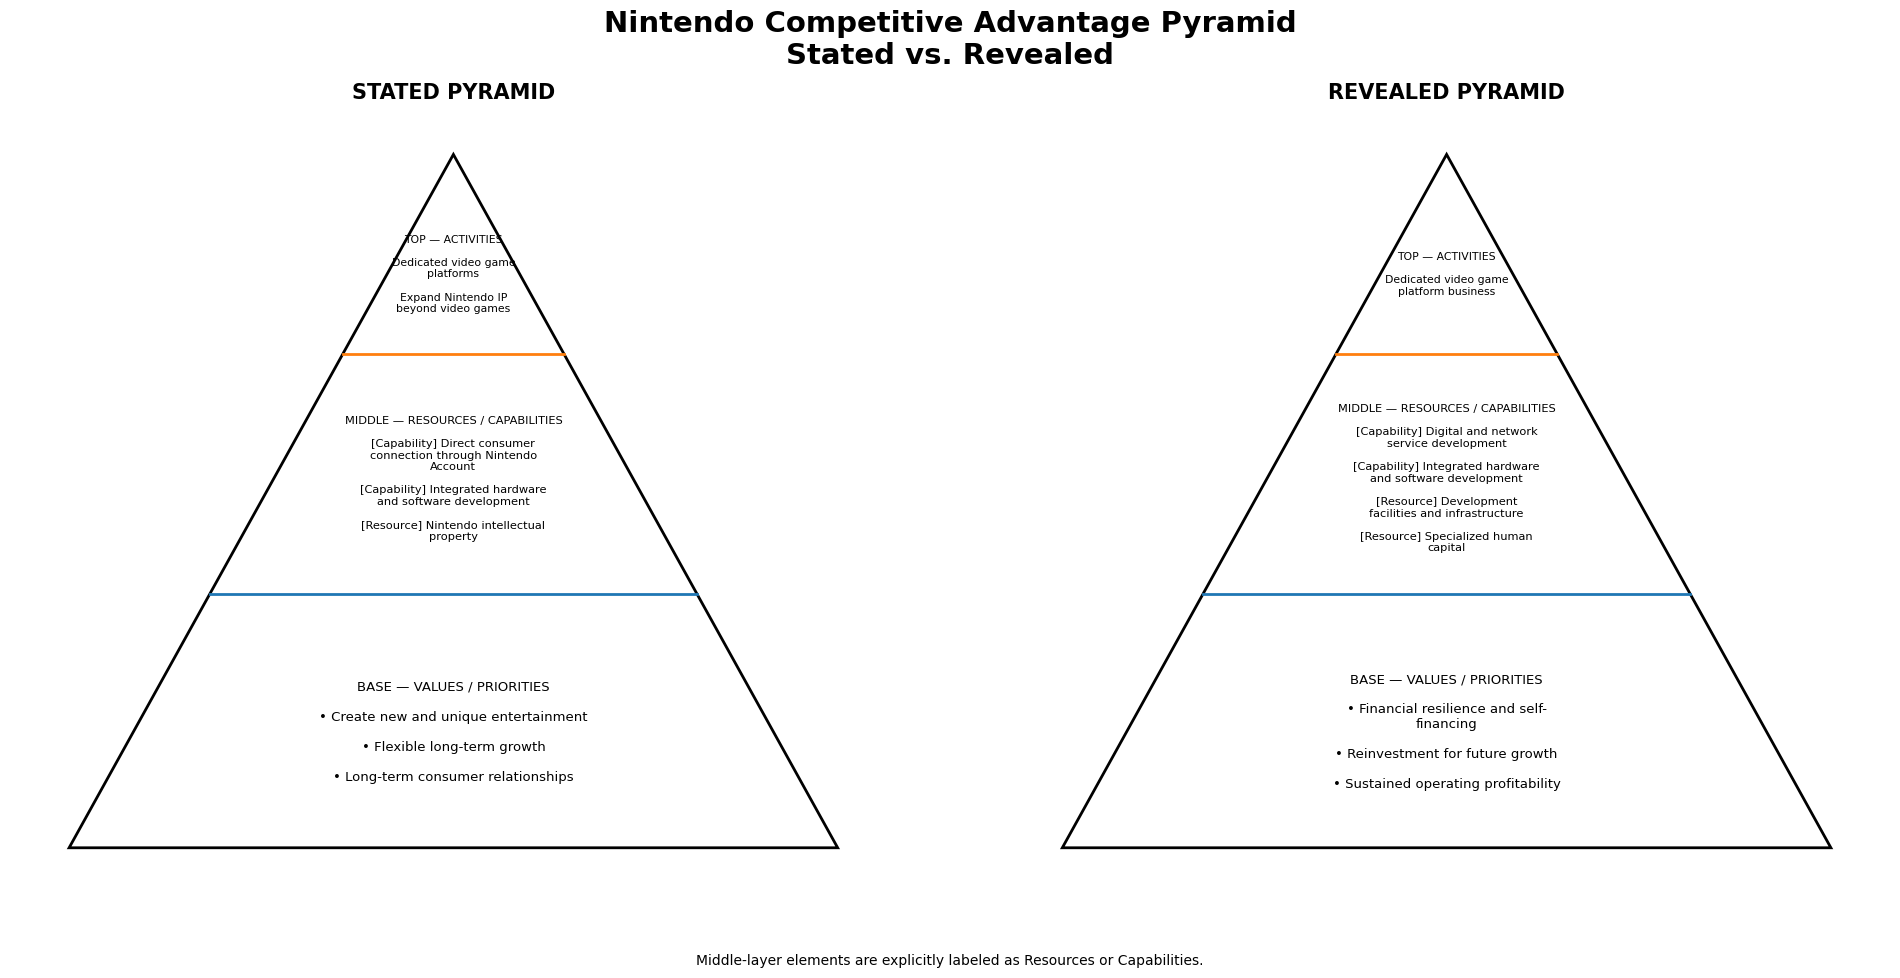

PYRAMID VISUAL CREATED
Saved to: c:\Users\steve\Documents\ACC 525\Nintendo-Competitive-Advantage-Pyramid\output\nintendo_stated_vs_revealed_pyramids.png
Stated elements shown: 8
Revealed elements shown: 8


In [92]:
# ============================================================
# CELL 13 — VISUALIZE STATED VS. REVEALED PYRAMIDS
# Straight-sided pyramid version
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import textwrap


# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------

def wrap_text(text, width=34):
    return "\n".join(textwrap.wrap(text, width=width))


def get_elements(df, layer):

    layer_df = df[df["layer"] == layer]

    elements = []

    for _, row in layer_df.iterrows():

        if layer == "Middle":
            label = f"[{row['classification']}] {row['element']}"
        else:
            label = row["element"]

        elements.append(label)

    return elements


def draw_pyramid(ax, df, title):

    ax.set_xlim(0, 12)
    ax.set_ylim(0, 9)
    ax.axis("off")

    # --------------------------------------------------------
    # ONE CONTINUOUS TRIANGLE
    # --------------------------------------------------------

    left_x = 0.8
    right_x = 11.2
    bottom_y = 0.7

    peak_x = 6.0
    peak_y = 8.5

    triangle = Polygon(
        [
            (left_x, bottom_y),
            (right_x, bottom_y),
            (peak_x, peak_y)
        ],
        closed=True,
        fill=False,
        linewidth=2
    )

    ax.add_patch(triangle)

    # --------------------------------------------------------
    # LAYER DIVIDERS
    #
    # Because the outside of the pyramid is one straight line,
    # calculate exactly where each horizontal divider intersects
    # the triangle.
    # --------------------------------------------------------

    middle_y = 3.55
    top_y = 6.25

    def triangle_width_at_y(y):

        fraction = (
            (y - bottom_y) /
            (peak_y - bottom_y)
        )

        left_intersection = (
            left_x +
            (peak_x - left_x) * fraction
        )

        right_intersection = (
            right_x -
            (right_x - peak_x) * fraction
        )

        return left_intersection, right_intersection

    middle_left, middle_right = triangle_width_at_y(middle_y)
    top_left, top_right = triangle_width_at_y(top_y)

    ax.plot(
        [middle_left, middle_right],
        [middle_y, middle_y],
        linewidth=2
    )

    ax.plot(
        [top_left, top_right],
        [top_y, top_y],
        linewidth=2
    )

    # --------------------------------------------------------
    # GET ELEMENTS
    # --------------------------------------------------------

    base_elements = get_elements(df, "Base")
    middle_elements = get_elements(df, "Middle")
    top_elements = get_elements(df, "Top")

    # --------------------------------------------------------
    # BASE
    # --------------------------------------------------------

    base_text = (
        "BASE — VALUES / PRIORITIES\n\n"
        + "\n\n".join(
            "• " + wrap_text(x, 38)
            for x in base_elements
        )
    )

    ax.text(
        6,
        2.0,
        base_text,
        ha="center",
        va="center",
        fontsize=9.5
    )

    # --------------------------------------------------------
    # MIDDLE
    # --------------------------------------------------------

    middle_text = (
        "MIDDLE — RESOURCES / CAPABILITIES\n\n"
        + "\n\n".join(
            wrap_text(x, 32)
            for x in middle_elements
        )
    )

    ax.text(
        6,
        4.85,
        middle_text,
        ha="center",
        va="center",
        fontsize=8.2
    )

    # --------------------------------------------------------
    # TOP
    # --------------------------------------------------------

    top_text = (
        "TOP — ACTIVITIES\n\n"
        + "\n\n".join(
            wrap_text(x, 24)
            for x in top_elements
        )
    )

    ax.text(
        6,
        7.15,
        top_text,
        ha="center",
        va="center",
        fontsize=7.8
    )

    # --------------------------------------------------------
    # TITLE
    # --------------------------------------------------------

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=8
    )


# ------------------------------------------------------------
# CREATE SIDE-BY-SIDE FIGURE
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 10)
)

draw_pyramid(
    axes[0],
    stated_pyramid_df,
    "STATED PYRAMID"
)

draw_pyramid(
    axes[1],
    revealed_pyramid_df,
    "REVEALED PYRAMID"
)

fig.suptitle(
    "Nintendo Competitive Advantage Pyramid\nStated vs. Revealed",
    fontsize=21,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,
    0.025,
    "Middle-layer elements are explicitly labeled as Resources or Capabilities.",
    ha="center",
    fontsize=10
)

plt.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.88,
    bottom=0.08,
    wspace=0.12
)


# ------------------------------------------------------------
# SAVE FIGURE
# ------------------------------------------------------------

pyramid_figure_path = (
    OUTPUT_DIR /
    "nintendo_stated_vs_revealed_pyramids.png"
)

plt.savefig(
    pyramid_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("=" * 80)
print("PYRAMID VISUAL CREATED")
print("=" * 80)

print(f"Saved to: {pyramid_figure_path}")
print(f"Stated elements shown: {len(stated_pyramid_df)}")
print(f"Revealed elements shown: {len(revealed_pyramid_df)}")

In [93]:
# ============================================================
# CELL 14 — FINAL GAP ANALYSIS OUTPUT
# ============================================================

# Pull only substantive gaps.
# Distance = 0 relationships are alignment evidence and remain
# available in gap_df, but the final gap table focuses on
# relationships where distance > 0.

final_gaps_df = (
    gap_df[
        gap_df["distance"] > 0
    ][
        [
            "layer",
            "stated_element",
            "revealed_element",
            "distance",
            "relationship",
            "evidence",
            "strategic_meaning"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

# Give each gap a readable identifier
final_gaps_df.insert(
    0,
    "gap",
    [
        f"Gap {i + 1}"
        for i in range(len(final_gaps_df))
    ]
)

# ------------------------------------------------------------
# SUMMARY METRICS
# ------------------------------------------------------------

distance_summary = {
    "comparisons_reviewed": len(gap_df),
    "total_distance": int(gap_df["distance"].sum()),
    "maximum_distance": int(len(gap_df) * 2),
    "average_distance": float(gap_df["distance"].mean()),
    "normalized_distance": float(
        gap_df["distance"].sum() /
        (len(gap_df) * 2)
    )
}

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

final_gaps_path = OUTPUT_DIR / "final_gap_analysis.csv"

final_gaps_df.to_csv(
    final_gaps_path,
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("FINAL GAP ANALYSIS")
print("=" * 80)

print(
    f"Pyramid distance: "
    f"{distance_summary['total_distance']} / "
    f"{distance_summary['maximum_distance']}"
)

print(
    f"Normalized distance: "
    f"{distance_summary['normalized_distance']:.1%}"
)

print(
    f"Substantive gaps identified: "
    f"{len(final_gaps_df)}"
)

print("\n" + "=" * 80)

for _, row in final_gaps_df.iterrows():

    print(f"\n{row['gap'].upper()}")
    print("-" * 80)

    print(f"Layer: {row['layer']}")
    print(f"Stated: {row['stated_element']}")
    print(f"Revealed: {row['revealed_element']}")
    print(f"Relationship: {row['relationship']}")
    print(f"Distance: {row['distance']} / 2")

    print("\nEvidence:")
    print(row["evidence"])

    print("\nStrategic meaning:")
    print(row["strategic_meaning"])

    print()


print("=" * 80)
print("ALIGNMENT CHECK")
print("=" * 80)

aligned_df = gap_df[
    gap_df["distance"] == 0
][
    [
        "layer",
        "stated_element",
        "revealed_element",
        "relationship"
    ]
].copy()

display(aligned_df)

FINAL GAP ANALYSIS
Pyramid distance: 2 / 8
Normalized distance: 25.0%
Substantive gaps identified: 2


GAP 1
--------------------------------------------------------------------------------
Layer: Top
Stated: Expand Nintendo IP beyond video games
Revealed: Dedicated video game platform business
Relationship: Tension / Partial alignment
Distance: 1 / 2

Evidence:
Nintendo states that it is expanding its IP through movies, videos, mobile applications, merchandise, and real-world experiences. However, FY2026 dedicated video game platform sales were ¥2,239.541 billion compared with ¥73.510 billion from IP-related income and other activities.

Strategic meaning:
Nintendo is pursuing broader uses of its IP, but its economic activity remains heavily concentrated in the dedicated gaming platform. This suggests diversification is currently an extension of the core platform strategy rather than a replacement for it.


GAP 2
------------------------------------------------------------------------

,layer,stated_element,revealed_element,relationship
0,Base,Create new and unique entertainment,Reinvestment for future growth,Aligned
1,Middle,Integrated hardware and software development,Integrated hardware and software development,Aligned


In [94]:
# ============================================================
# CELL 15 — LARGE PUBLIC COMPANY TRACK ANALYSIS
# ============================================================

track_analysis = """
Nintendo's stated and revealed competitive advantage pyramids show more
alignment than contradiction. The evidence suggests that the gaps between
the two are better characterized as deliberate strategic positioning with
meaningful tensions rather than broad strategic misalignment.

The clearest alignment is Nintendo's emphasis on creating new and unique
entertainment. Nintendo's revealed behavior supports this priority through
substantial reinvestment in research, technology, and development. FY2026
research and development expense was ¥177.8 billion, and Nintendo also
continued investing in development facilities and infrastructure. The
company's stated reliance on integrated hardware and software development
is similarly supported by its actual R&D activities. This capability appears
in both pyramids and represents one of the strongest areas of consistency
between what Nintendo says and what it does.

The first substantive gap concerns Nintendo's expansion beyond video games.
Nintendo states that it wants consumers to experience its intellectual
property through movies and videos, mobile applications, merchandise, and
real-world experiences. Its revealed economic activity, however, remains
heavily concentrated in dedicated video game platforms. FY2026 dedicated
video game platform sales were ¥2,239.541 billion compared with ¥73.510
billion from IP-related income and other activities. This appears less like
a contradiction than a deliberate adjacency strategy: Nintendo is extending
its IP into additional forms of entertainment while keeping its gaming
platform at the economic center of the business.

The second tension concerns flexibility and financial discipline. Nintendo
states that it avoids specific management index targets because uncertainty
in entertainment requires flexible decision-making. Yet operating profit
plays a significant role in executive performance compensation and dividend
policy. This creates a measurable financial discipline beneath a strategy
that publicly emphasizes flexibility. Importantly, the compensation structure
also incorporates a three-year operating-profit measure and restricted stock,
so the evidence does not support interpreting Nintendo as focused solely on
short-term performance.

Overall, the revealed pyramid largely supports Nintendo's stated strategy,
while showing where economic concentration and financial incentives place
practical boundaries around that strategy. The gaps therefore reveal how
Nintendo implements its positioning rather than demonstrating that its stated
strategy is disconnected from its behavior.
""".strip()


# ------------------------------------------------------------
# SAVE ANALYSIS
# ------------------------------------------------------------

track_analysis_path = OUTPUT_DIR / "track_analysis.txt"

with open(
    track_analysis_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(track_analysis)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

word_count = len(track_analysis.split())

print("LARGE PUBLIC COMPANY TRACK ANALYSIS")
print("=" * 80)

print(f"Word count: {word_count}")
print(f"Saved to: {track_analysis_path}")

print("\n" + track_analysis)

LARGE PUBLIC COMPANY TRACK ANALYSIS
Word count: 339
Saved to: c:\Users\steve\Documents\ACC 525\Nintendo-Competitive-Advantage-Pyramid\output\track_analysis.txt

Nintendo's stated and revealed competitive advantage pyramids show more
alignment than contradiction. The evidence suggests that the gaps between
the two are better characterized as deliberate strategic positioning with
meaningful tensions rather than broad strategic misalignment.

The clearest alignment is Nintendo's emphasis on creating new and unique
entertainment. Nintendo's revealed behavior supports this priority through
substantial reinvestment in research, technology, and development. FY2026
research and development expense was ¥177.8 billion, and Nintendo also
continued investing in development facilities and infrastructure. The
company's stated reliance on integrated hardware and software development
is similarly supported by its actual R&D activities. This capability appears
in both pyramids and represents one of the

In [95]:
# ============================================================
# CELL 16 — REFLECTION
# ============================================================

reflection = """
The hardest part of building this tool was that Nintendo is not a U.S.
company. The assignment uses sources such as the 10-K and DEF 14A, but
Nintendo is a Japanese public company and does not file those same documents.
At first, I was not sure how I was going to get comparable information. I
ended up finding Nintendo's Japanese equivalents, including its Annual Report,
shareholder meeting materials, governance information, and financial
disclosures. This actually made the project more interesting because I had
to think about what information the assignment was really asking for instead
of just looking for a document with the right name.

One specific decision this tool cannot support is telling Nintendo management
what its next strategic move should be. The tool can show differences between
Nintendo's stated goals and what its public behavior seems to reveal, but
there are other things going on inside the company that we do not know about.
Nintendo could have private goals involving unreleased games, future consoles,
movies, partnerships, or the types of games it wants to develop. Those plans
could completely change how management should make a decision, and this tool
only has access to public information.

The Revealed Pyramid could also be wrong because behavioral evidence still
requires interpretation. Nintendo has its hands in a lot of different places.
It makes video games and consoles, uses its IP in movies and merchandise, and
is connected to businesses such as Pokémon. Looking at one piece of evidence
could make it seem like Nintendo has one company-wide priority when the
evidence may really apply to only one part of the business. Revenue can also
be misleading because it shows what is making money now, not necessarily what
Nintendo is trying to build for the future. For example, Nintendo's gaming
platform currently produces far more revenue than its other IP-related
activities, but that does not mean its expansion into movies and other
experiences is unimportant. The tool is useful for identifying gaps, but those
gaps still need context before deciding what they mean.
""".strip()


reflection_path = OUTPUT_DIR / "reflection.txt"

with open(
    reflection_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(reflection)


word_count = len(reflection.split())

print("REFLECTION")
print("=" * 80)
print(f"Word count: {word_count}")
print(f"Within required 250–500 words: {250 <= word_count <= 500}")
print(f"Saved to: {reflection_path}")

print("\n" + reflection)

REFLECTION
Word count: 341
Within required 250–500 words: True
Saved to: c:\Users\steve\Documents\ACC 525\Nintendo-Competitive-Advantage-Pyramid\output\reflection.txt

The hardest part of building this tool was that Nintendo is not a U.S.
company. The assignment uses sources such as the 10-K and DEF 14A, but
Nintendo is a Japanese public company and does not file those same documents.
At first, I was not sure how I was going to get comparable information. I
ended up finding Nintendo's Japanese equivalents, including its Annual Report,
shareholder meeting materials, governance information, and financial
disclosures. This actually made the project more interesting because I had
to think about what information the assignment was really asking for instead
of just looking for a document with the right name.

One specific decision this tool cannot support is telling Nintendo management
what its next strategic move should be. The tool can show differences between
Nintendo's stated goals and w

In [96]:
# ============================================================
# CELL 17 — FINAL PYRAMID EVIDENCE + CITATION TABLE
# ============================================================

# PURPOSE:
# Create one master evidence table for the final submission.
#
# Every Stated and Revealed pyramid element retains:
#   - document
#   - section
#   - printed page
#   - PDF page
#   - evidence
#   - interpretation
#
# Multiple evidence rows are intentionally preserved when
# more than one source supports the same revealed element.


# ------------------------------------------------------------
# STANDARDIZE STATED EVIDENCE
# ------------------------------------------------------------

stated_final_evidence = stated_evidence_df[
    [
        "pyramid",
        "layer",
        "classification",
        "element",
        "evidence",
        "interpretation",
        "document",
        "section",
        "printed_page",
        "pdf_page"
    ]
].copy()


# ------------------------------------------------------------
# STANDARDIZE REVEALED EVIDENCE
# ------------------------------------------------------------

revealed_final_evidence = curated_evidence_df[
    [
        "pyramid",
        "layer",
        "classification",
        "element",
        "evidence",
        "interpretation",
        "document",
        "section",
        "printed_page",
        "pdf_page"
    ]
].copy()


# ------------------------------------------------------------
# COMBINE
# ------------------------------------------------------------

final_evidence_df = pd.concat(
    [
        stated_final_evidence,
        revealed_final_evidence
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# CREATE HUMAN-READABLE CITATION
# ------------------------------------------------------------

final_evidence_df["citation"] = (
    final_evidence_df["document"].astype(str)
    + " | "
    + final_evidence_df["section"].astype(str)
    + " | printed p. "
    + final_evidence_df["printed_page"].astype(str)
    + " | PDF p. "
    + final_evidence_df["pdf_page"].astype(str)
)


# ------------------------------------------------------------
# ORDER FOR FINAL OUTPUT
# ------------------------------------------------------------

layer_order = {
    "Base": 1,
    "Middle": 2,
    "Top": 3
}

pyramid_order = {
    "Stated": 1,
    "Revealed": 2
}

final_evidence_df["pyramid_order"] = (
    final_evidence_df["pyramid"].map(pyramid_order)
)

final_evidence_df["layer_order"] = (
    final_evidence_df["layer"].map(layer_order)
)

final_evidence_df = (
    final_evidence_df
    .sort_values(
        [
            "pyramid_order",
            "layer_order",
            "classification",
            "element"
        ]
    )
    .drop(
        columns=[
            "pyramid_order",
            "layer_order"
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

final_evidence_path = (
    OUTPUT_DIR /
    "final_pyramid_evidence_with_citations.csv"
)

final_evidence_df.to_csv(
    final_evidence_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("FINAL PYRAMID EVIDENCE + CITATION TABLE")
print("=" * 80)

print(f"Loaded successfully: {not final_evidence_df.empty}")
print(f"Evidence rows: {len(final_evidence_df)}")
print(f"Missing cells: {final_evidence_df.isna().sum().sum()}")
print(f"Duplicate rows: {final_evidence_df.duplicated().sum()}")

print("\nEvidence rows by pyramid:")
print(final_evidence_df["pyramid"].value_counts())

print("\nDistinct elements by pyramid:")
print(
    final_evidence_df
    .groupby("pyramid")["element"]
    .nunique()
)

print("\nCitation preview:")

display(
    final_evidence_df[
        [
            "pyramid",
            "layer",
            "classification",
            "element",
            "citation"
        ]
    ]
)

FINAL PYRAMID EVIDENCE + CITATION TABLE
Loaded successfully: True
Evidence rows: 18
Missing cells: 0
Duplicate rows: 0

Evidence rows by pyramid:
pyramid
Revealed    10
Stated       8
Name: count, dtype: int64

Distinct elements by pyramid:
pyramid
Revealed    8
Stated      8
Name: element, dtype: int64

Citation preview:


,pyramid,layer,classification,element,citation
0,Stated,Base,Priority,Create new and unique entertainment,Nintendo Annual Report 2026 | Basic management...
1,Stated,Base,Priority,Flexible long-term growth,Nintendo Annual Report 2026 | Targeted managem...
2,Stated,Base,Priority,Long-term consumer relationships,Nintendo Annual Report 2026 | Management envir...
3,Stated,Middle,Capability,Direct consumer connection through Nintendo Ac...,Nintendo Annual Report 2026 | Management envir...
4,Stated,Middle,Capability,Integrated hardware and software development,Nintendo Annual Report 2026 | Management envir...
5,Stated,Middle,Resource,Nintendo intellectual property,Nintendo Annual Report 2026 | Management envir...
6,Stated,Top,Activity,Dedicated video game platforms,Nintendo Annual Report 2026 | Management envir...
7,Stated,Top,Activity,Expand Nintendo IP beyond video games,Nintendo Annual Report 2026 | Management envir...
8,Revealed,Base,Priority,Financial resilience and self-financing,Nintendo Annual Report 2026 | Financial source...
9,Revealed,Base,Priority,Reinvestment for future growth,Nintendo Annual Report 2026 | Dividend policy ...


In [ ]:
# ============================================================
# CELL 18 — CREATE FINAL SUBMISSION PDF
# ============================================================

# Install ReportLab automatically if it is not already available
try:
    import reportlab
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "reportlab"
    ])

from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from reportlab.lib.pagesizes import letter, landscape
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from reportlab.lib.pagesizes import letter, landscape
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    PageBreak,
    Image,
    KeepTogether
)
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfbase import pdfmetrics
from pathlib import Path
import os


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

TOOL_URL = "PASTE_PUBLIC_GITHUB_OR_COLAB_LINK_HERE"

FINAL_PDF = OUTPUT_DIR / "Nintendo_Competitive_Advantage_Pyramid_Final.pdf"


# ------------------------------------------------------------
# DOCUMENT SETUP
# ------------------------------------------------------------

doc = SimpleDocTemplate(
    str(FINAL_PDF),
    pagesize=letter,
    rightMargin=0.55 * inch,
    leftMargin=0.55 * inch,
    topMargin=0.55 * inch,
    bottomMargin=0.55 * inch
)

styles = getSampleStyleSheet()

title_style = ParagraphStyle(
    "TitleCustom",
    parent=styles["Title"],
    fontSize=20,
    leading=24,
    alignment=TA_CENTER,
    spaceAfter=14
)

subtitle_style = ParagraphStyle(
    "Subtitle",
    parent=styles["Normal"],
    fontSize=11,
    leading=15,
    alignment=TA_CENTER,
    spaceAfter=12
)

heading_style = ParagraphStyle(
    "HeadingCustom",
    parent=styles["Heading1"],
    fontSize=15,
    leading=18,
    spaceBefore=4,
    spaceAfter=10
)

subheading_style = ParagraphStyle(
    "SubheadingCustom",
    parent=styles["Heading2"],
    fontSize=11.5,
    leading=14,
    spaceBefore=7,
    spaceAfter=5
)

body_style = ParagraphStyle(
    "BodyCustom",
    parent=styles["BodyText"],
    fontSize=9.5,
    leading=13,
    spaceAfter=7
)

small_style = ParagraphStyle(
    "SmallCustom",
    parent=styles["BodyText"],
    fontSize=7.5,
    leading=10
)

citation_style = ParagraphStyle(
    "CitationCustom",
    parent=styles["BodyText"],
    fontSize=7.2,
    leading=9,
    textColor=colors.HexColor("#333333")
)

gap_style = ParagraphStyle(
    "GapCustom",
    parent=styles["BodyText"],
    fontSize=9,
    leading=12,
    spaceAfter=5
)


# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------

def safe(value):
    return str(value).replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")


def add_page_number(canvas, doc):
    canvas.saveState()
    canvas.setFont("Helvetica", 8)
    canvas.drawRightString(
        letter[0] - 0.55 * inch,
        0.3 * inch,
        f"Page {doc.page}"
    )
    canvas.restoreState()


def citation_text(row):
    return (
        f"{safe(row['document'])}; "
        f"{safe(row['section'])}; "
        f"printed p. {safe(row['printed_page'])}; "
        f"PDF p. {safe(row['pdf_page'])}"
    )


story = []


# ============================================================
# PAGE 1 — TITLE / TOOL / METHOD
# ============================================================

story.append(
    Paragraph(
        "Nintendo Competitive Advantage Pyramid",
        title_style
    )
)

story.append(
    Paragraph(
        "Stated vs. Revealed Strategy",
        subtitle_style
    )
)

story.append(Spacer(1, 0.08 * inch))

story.append(
    Paragraph(
        "<b>Working Tool:</b><br/>"
        f'<link href="{TOOL_URL}" color="blue">{safe(TOOL_URL)}</link>',
        body_style
    )
)

story.append(Spacer(1, 0.12 * inch))

story.append(
    Paragraph(
        "Methodology",
        heading_style
    )
)

methodology = """
The tool uses a documented evidence pipeline rather than automatically
assigning strategy from keywords. Source PDFs are first converted into
page-level text. A high-recall keyword search identifies candidate evidence,
which is then ranked and manually reviewed. Evidence is classified by pyramid
layer, and middle-layer elements are explicitly classified as either Resources
or Capabilities. The final evidence register retains the document, section,
printed page, PDF page, evidence, and interpretation for each element.
"""

story.append(Paragraph(methodology.strip(), body_style))

story.append(
    Paragraph(
        "<b>Stated Pyramid:</b> Built only from Nintendo's descriptions of its "
        "priorities, strategy, resources, capabilities, and activities.",
        body_style
    )
)

story.append(
    Paragraph(
        "<b>Revealed Pyramid:</b> Built from observable evidence such as "
        "capital allocation, R&amp;D spending, executive incentives, facilities, "
        "workforce, development activity, and revenue concentration.",
        body_style
    )
)

story.append(
    Paragraph(
        "<b>Distance Method:</b> Defensible strategic counterparts were manually "
        "compared using a 0–2 scale: 0 = Aligned, 1 = Tension / Partial "
        "Alignment, and 2 = Divergence. Elements were not forced into artificial "
        "pairings when no meaningful counterpart existed. The resulting distance "
        "is therefore a transparent comparison index, not a percentage of "
        "dishonesty or strategic failure.",
        body_style
    )
)

story.append(
    Paragraph(
        "Source Substitution Note",
        heading_style
    )
)

source_note = """
Nintendo is a Japanese public company, so the U.S. DEF 14A and 10-K sources
referenced in the assignment are not available in the same form. The analysis
therefore uses Nintendo's Japanese-equivalent corporate disclosures and
official investor-relations materials, including its Annual Report and
shareholder materials. The Annual Report itself is based on Nintendo's Annual
Securities Report prepared under Japan's Financial Instruments and Exchange Act.
"""

story.append(Paragraph(source_note.strip(), body_style))

story.append(PageBreak())


# ============================================================
# PAGE 2 — SIDE-BY-SIDE PYRAMIDS
# ============================================================

story.append(
    Paragraph(
        "Stated vs. Revealed Competitive Advantage Pyramids",
        heading_style
    )
)

story.append(
    Paragraph(
        "Middle-layer elements are explicitly labeled as Resources or Capabilities.",
        body_style
    )
)

if pyramid_figure_path.exists():
    pyramid_img = Image(
        str(pyramid_figure_path),
        width=7.35 * inch,
        height=3.68 * inch
    )
    story.append(pyramid_img)

story.append(Spacer(1, 0.12 * inch))

story.append(
    Paragraph(
        "<b>Interpretation:</b> The two pyramids show substantial alignment in "
        "Nintendo's commitment to innovation and integrated hardware/software "
        "development. The most meaningful differences concern the scale of its "
        "non-gaming IP expansion and the role of operating-profit discipline.",
        body_style
    )
)

story.append(PageBreak())


# ============================================================
# PAGES 3–4 — EVIDENCE AND CITATIONS
# ============================================================

for pyramid_name in ["Stated", "Revealed"]:

    story.append(
        Paragraph(
            f"{pyramid_name} Pyramid — Evidence and Sources",
            heading_style
        )
    )

    pyramid_evidence = final_evidence_df[
        final_evidence_df["pyramid"] == pyramid_name
    ]

    for layer in ["Base", "Middle", "Top"]:

        layer_df = pyramid_evidence[
            pyramid_evidence["layer"] == layer
        ]

        if layer_df.empty:
            continue

        story.append(
            Paragraph(
                layer.upper(),
                subheading_style
            )
        )

        for element in layer_df["element"].unique():

            element_rows = layer_df[
                layer_df["element"] == element
            ]

            first = element_rows.iloc[0]

            if layer == "Middle":
                element_title = (
                    f"<b>{safe(element)}</b> "
                    f"({safe(first['classification'])})"
                )
            else:
                element_title = f"<b>{safe(element)}</b>"

            story.append(
                Paragraph(
                    element_title,
                    body_style
                )
            )

            for _, row in element_rows.iterrows():

                story.append(
                    Paragraph(
                        f"<b>Evidence:</b> {safe(row['evidence'])}",
                        small_style
                    )
                )

                story.append(
                    Paragraph(
                        f"<b>Source:</b> {citation_text(row)}",
                        citation_style
                    )
                )

            story.append(Spacer(1, 0.06 * inch))

    story.append(PageBreak())


# ============================================================
# PAGE 5 — GAP ANALYSIS
# ============================================================

story.append(
    Paragraph(
        "Stated vs. Revealed Gap Analysis",
        heading_style
    )
)

story.append(
    Paragraph(
        f"<b>Pyramid distance:</b> "
        f"{distance_summary['total_distance']} / "
        f"{distance_summary['maximum_distance']} "
        f"({distance_summary['normalized_distance']:.0%} normalized distance)",
        body_style
    )
)

story.append(
    Paragraph(
        "The normalized distance is based only on the four strategic comparisons "
        "for which a defensible Stated/Revealed counterpart was identified. It "
        "should be interpreted as a structured comparison measure rather than a "
        "complete quantitative measure of Nintendo's strategy.",
        body_style
    )
)

for _, row in final_gaps_df.iterrows():

    gap_block = []

    gap_block.append(
        Paragraph(
            f"<b>{safe(row['gap'])}: "
            f"{safe(row['stated_element'])} vs. "
            f"{safe(row['revealed_element'])}</b>",
            subheading_style
        )
    )

    gap_block.append(
        Paragraph(
            f"<b>Relationship:</b> {safe(row['relationship'])} "
            f"(Distance {safe(row['distance'])}/2)",
            gap_style
        )
    )

    gap_block.append(
        Paragraph(
            f"<b>Evidence:</b> {safe(row['evidence'])}",
            gap_style
        )
    )

    gap_block.append(
        Paragraph(
            f"<b>Strategic meaning:</b> "
            f"{safe(row['strategic_meaning'])}",
            gap_style
        )
    )

    story.append(KeepTogether(gap_block))
    story.append(Spacer(1, 0.08 * inch))


story.append(
    Paragraph(
        "Areas of Alignment",
        subheading_style
    )
)

for _, row in aligned_df.iterrows():
    story.append(
        Paragraph(
            f"• <b>{safe(row['stated_element'])}</b> → "
            f"{safe(row['revealed_element'])}: "
            f"{safe(row['relationship'])}",
            body_style
        )
    )

story.append(PageBreak())


# ============================================================
# PAGE 6 — LARGE PUBLIC COMPANY TRACK
# ============================================================

story.append(
    Paragraph(
        "Large Public Company Track Analysis",
        heading_style
    )
)

for paragraph in track_analysis.split("\n\n"):
    story.append(
        Paragraph(
            safe(paragraph),
            body_style
        )
    )

story.append(PageBreak())


# ============================================================
# PAGE 7 — REFLECTION
# ============================================================

story.append(
    Paragraph(
        "Reflection",
        heading_style
    )
)

story.append(
    Paragraph(
        f"<b>Word count:</b> {len(reflection.split())}",
        small_style
    )
)

story.append(Spacer(1, 0.08 * inch))

for paragraph in reflection.split("\n\n"):
    story.append(
        Paragraph(
            safe(paragraph),
            body_style
        )
    )


# ============================================================
# BUILD PDF
# ============================================================

doc.build(
    story,
    onFirstPage=add_page_number,
    onLaterPages=add_page_number
)


# ------------------------------------------------------------
# FINAL VALIDATION
# ------------------------------------------------------------

print("FINAL SUBMISSION PDF")
print("=" * 80)
print(f"Created successfully: {FINAL_PDF.exists()}")
print(f"File: {FINAL_PDF}")
print(f"File size: {FINAL_PDF.stat().st_size:,} bytes")

if TOOL_URL == "PASTE_PUBLIC_GITHUB_OR_COLAB_LINK_HERE":
    print("\nWARNING:")
    print("The PDF still contains the placeholder tool URL.")
    print("Publish the tool, replace TOOL_URL, and rerun this cell before submission.")
else:
    print("\nTool URL has been added.")

FINAL SUBMISSION PDF
Created successfully: True
File: c:\Users\steve\Documents\ACC 525\Nintendo-Competitive-Advantage-Pyramid\output\Nintendo_Competitive_Advantage_Pyramid_Final.pdf
File size: 604,852 bytes

The PDF still contains the placeholder tool URL.
Publish the tool, replace TOOL_URL, and rerun this cell before submission.
